# 07 — EfficientNet-B0 (pretrained ImageNet)

In [2]:
import sys
import time
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from pathlib import Path

from eval import LABEL_ORDER
from utils import (
    set_seed, load_dataset, split_dataset,
    get_train_transform, get_eval_transform, build_dataloaders,
    train_model, save_checkpoint, load_checkpoint,
    plot_training_history, print_model_info,
    compute_multilabel_metrics, evaluate_predictor,
    print_metric_table, NUM_LABELS, METRIC_KEYS,
)

SEED = 42
set_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Labels ({NUM_LABELS}): {LABEL_ORDER}")


Device: cuda
Labels (12): ['pen', 'paper', 'book', 'clock', 'phone', 'laptop', 'chair', 'desk', 'bottle', 'keychain', 'backpack', 'calculator']


In [3]:
BASE_DIR        = "../data/aggregated"
IMAGE_SIZE      = 224
BATCH_SIZE      = 64
SPLIT           = [0.7, 0.15, 0.15]
CHECKPOINT_DIR  = Path("../checkpoints")
EXPERIMENT_NAME = "efficientnet_b0_pretrained"
MODEL_PATH      = CHECKPOINT_DIR / f"final_{EXPERIMENT_NAME}.pth"

full_dataset = load_dataset(BASE_DIR)
train_raw, val_raw, test_raw = split_dataset(full_dataset, SPLIT, SEED)

train_transform = get_train_transform(IMAGE_SIZE)
eval_transform  = get_eval_transform(IMAGE_SIZE)
train_loader, val_loader, test_loader = build_dataloaders(
    train_raw, val_raw, test_raw, train_transform, eval_transform,
    batch_size=BATCH_SIZE,
)
print(f"Train: {len(train_raw)}  |  Val: {len(val_raw)}  |  Test: {len(test_raw)}")


Train: 3180  |  Val: 681  |  Test: 682


## Model Definition

In [4]:
from torchvision import models as tv_models

def create_model(num_labels):
    m = tv_models.efficientnet_b0(weights=tv_models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    in_features = m.classifier[-1].in_features
    m.classifier[-1] = nn.Linear(in_features, num_labels)
    return m

print_model_info(create_model(NUM_LABELS))


  Total params     :    4,022,920
  Trainable params :    4,022,920  (100.0%)
  Model size       : 15.35 MB  (float32 weights)


## Grid Search (LR × WD)

In [6]:
GRID = [
    {"lr": 1e-3, "wd": 1e-4},
    {"lr": 1e-4, "wd": 1e-4},
]

grid_results = []
for cfg in GRID:
    print(f"\n--- lr={cfg['lr']:.0e}  wd={cfg['wd']:.0e} ---")
    state, val_f1, _, epochs_run = train_model(
        create_model, NUM_LABELS, train_loader, val_loader, DEVICE,
        lr=cfg["lr"], weight_decay=cfg["wd"],
        max_epochs=20, warmup_epochs=2, early_stop_patience=5,
    )
    grid_results.append({**cfg, "val_f1": val_f1, "state": state, "epochs": epochs_run})
    print(f"  => val F1: {val_f1:.4f}")

grid_results.sort(key=lambda x: x["val_f1"], reverse=True)
best = grid_results[0]
print(f"\nBest config: lr={best['lr']:.0e}  wd={best['wd']:.0e}  val_F1={best['val_f1']:.4f}")

rows = [{"lr": c["lr"], "wd": c["wd"], "val_f1": round(c["val_f1"], 4), "epochs": c["epochs"]}
        for c in grid_results]
print(pd.DataFrame(rows).to_string(index=False))



--- lr=1e-03  wd=1e-04 ---

Epoch  1/20  [lr=5.00e-04]
  Metric                  Train       Val
  ----------------------------------------
  loss                   0.3400    0.1976
  exact_match            0.2044    0.4317
  hamming_acc            0.8721    0.9280
  mean_iou               0.3234    0.6385
  precision_micro        0.6364    0.8787
  recall_micro           0.2977    0.5917
  f1_micro               0.4056    0.7072

Epoch  2/20  [lr=1.00e-03]
  Metric                  Train       Val
  ----------------------------------------
  loss                   0.1873    0.1762
  exact_match            0.4855    0.5110
  hamming_acc            0.9335    0.9394
  mean_iou               0.6829    0.7206
  precision_micro        0.8639    0.8466
  recall_micro           0.6489    0.7175
  f1_micro               0.7411    0.7767

Epoch  3/20  [lr=1.00e-03]
  Metric                  Train       Val
  ----------------------------------------
  loss                   0.1436    0.1562
  e

## Final Training


Epoch  1/60  [lr=2.00e-04]
  Metric                  Train       Val
  ----------------------------------------
  loss                   0.4570    0.2888
  exact_match            0.0695    0.1645
  hamming_acc            0.8182    0.8855
  mean_iou               0.1459    0.2757
  precision_micro        0.3050    0.9342
  recall_micro           0.1875    0.2367
  f1_micro               0.2322    0.3777

Epoch  2/60  [lr=4.00e-04]
  Metric                  Train       Val
  ----------------------------------------
  loss                   0.2356    0.1689
  exact_match            0.3528    0.4919
  hamming_acc            0.9150    0.9381
  mean_iou               0.5397    0.6985
  precision_micro        0.8823    0.8952
  recall_micro           0.4848    0.6550
  f1_micro               0.6258    0.7565

Epoch  3/60  [lr=6.00e-04]
  Metric                  Train       Val
  ----------------------------------------
  loss                   0.1602    0.1445
  exact_match            0.5343

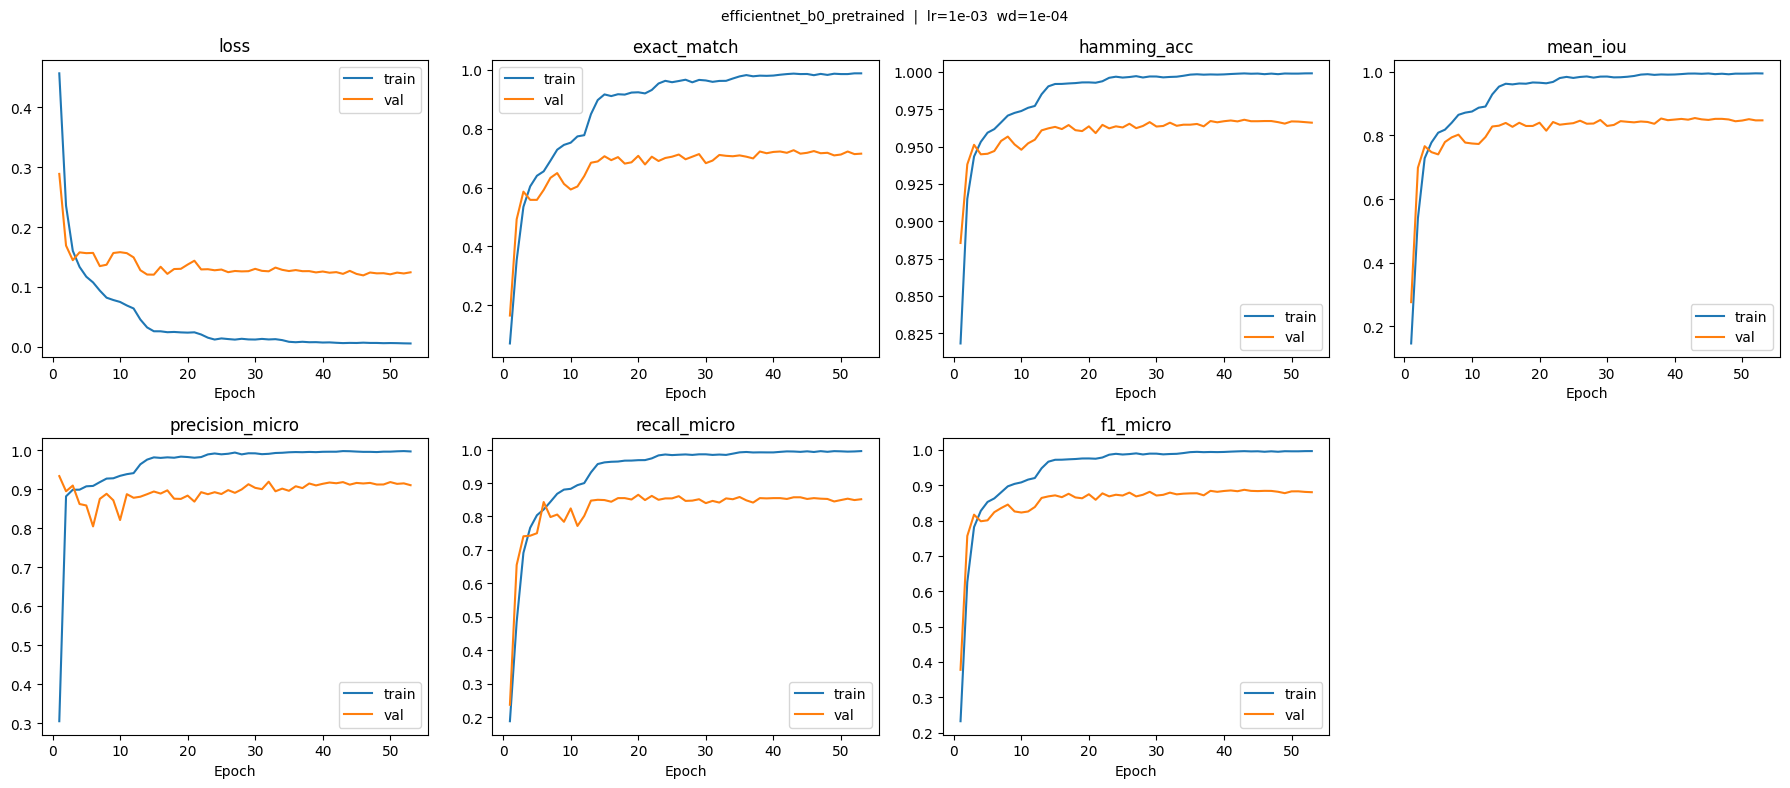

In [7]:
t0 = time.time()
best_state, best_val_f1, history, epochs_run = train_model(
    create_model, NUM_LABELS, train_loader, val_loader, DEVICE,
    lr=best["lr"], weight_decay=best["wd"],
    max_epochs=60, warmup_epochs=5, early_stop_patience=10,
)
training_time = time.time() - t0
print(f"\nBest val F1: {best_val_f1:.4f}  |  Epochs: {epochs_run}  |  Time: {training_time:.1f}s")

save_checkpoint(best_state, MODEL_PATH)
plot_training_history(history, epochs_run, EXPERIMENT_NAME, best["lr"], best["wd"])


## Evaluation

In [8]:
model = load_checkpoint(create_model, NUM_LABELS, MODEL_PATH, DEVICE)
model.eval()

def _predict(images, threshold=0.5):
    with torch.no_grad():
        logits = model(images)
        probs  = torch.sigmoid(logits)
        preds  = (probs >= threshold).float()
    return preds, probs, logits

val_metrics  = evaluate_predictor(val_loader,  _predict, DEVICE)
test_metrics = evaluate_predictor(test_loader, _predict, DEVICE)

rows = [
    {"split": "val",  **{k: round(val_metrics[k],  4) for k in METRIC_KEYS}},
    {"split": "test", **{k: round(test_metrics[k], 4) for k in METRIC_KEYS}},
]
df = pd.DataFrame(rows).set_index("split")
print(df.to_string())


         loss  exact_match  hamming_acc  mean_iou  precision_micro  recall_micro  f1_micro
split                                                                                     
val    0.1217       0.7269       0.9679    0.8546           0.9187        0.8575    0.8871
test   0.1367       0.7214       0.9646    0.8396           0.9055        0.8447    0.8740


In [9]:

print("\nModel summary:")
print_model_info(create_model(NUM_LABELS))
print(f"Training time : {training_time:.1f}s")



Model summary:
  Total params     :    4,022,920
  Trainable params :    4,022,920  (100.0%)
  Model size       : 15.35 MB  (float32 weights)
Training time : 812.2s
